In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv("Salary_Data.csv")
data.head()

,YearsExperience,Age,Salary
0,1.1,21.0,39343
1,1.3,21.5,46205
2,1.5,21.7,37731
3,2.0,22.0,43525
4,2.2,22.2,39891


In [4]:
data.shape

(30, 3)

In [5]:
data.isnull().sum()

YearsExperience    0
Age                0
Salary             0
dtype: int64

In [6]:
def custom_round(x):
    integer = int(x)
    decimal = x - integer

    if decimal >= 0.8:
        return integer + 1
    else:
        return integer

data['YearsExperience'] = data['YearsExperience'].apply(custom_round)

In [9]:
def custom_round(x):
    integer = int(x)
    decimal = x - integer

    if decimal >= 0.8:
        return integer + 1
    else:
        return integer

data['Age'] = data['Age'].apply(custom_round)

In [10]:
data.head()

,YearsExperience,Age,Salary
0,1,21,39343
1,1,21,46205
2,1,21,37731
3,2,22,43525
4,2,22,39891


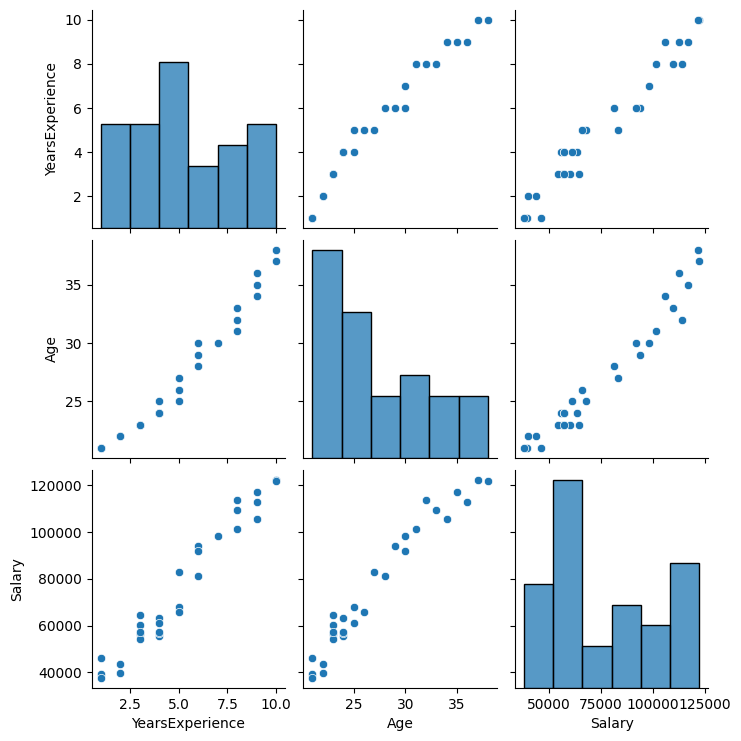

In [ ]:
sns.pairplot(data=data)
plt.show()

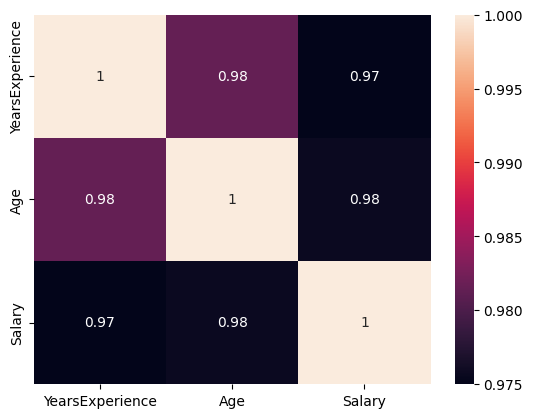

In [12]:
sns.heatmap(data=data.corr(),annot=True)
plt.show()

In [13]:
x_input = data.iloc[:,:-1]
y_output = data["Salary"]

In [14]:
x_input.head()

,YearsExperience,Age
0,1,21
1,1,21
2,1,21
3,2,22
4,2,22


In [15]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x_input,y_output,test_size=0.2,random_state=42)

In [16]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [17]:
lr.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[3543.69,3325.66]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['YearsExperience','Age']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-3.33e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,2


In [22]:
lr.coef_, lr.intercept_

(array([3543.69439849, 3325.66012763]), np.float64(-33303.67043843058))

In [21]:
lr.score(x_test,y_test)*100

87.34141489835274

In [32]:
lr.predict([[5,21]])

d:\Data Science\.All_venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([54253.66423422])

In [37]:
y_prd = lr.predict(x_input)

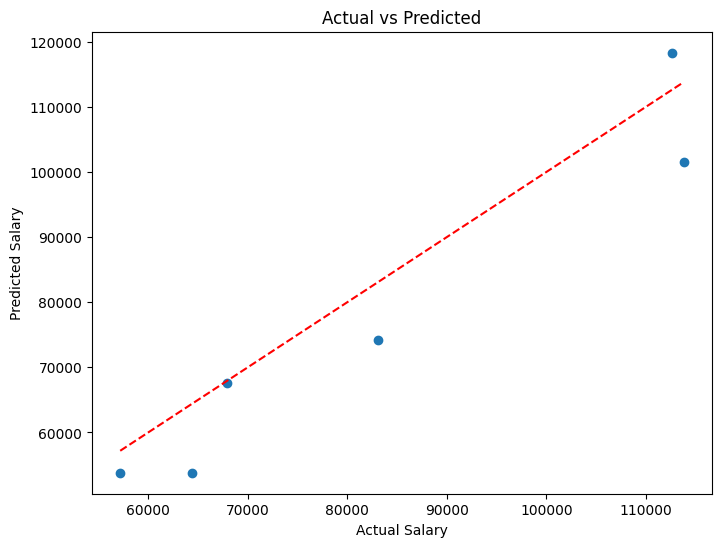

In [44]:
y_pred = lr.predict(x_test)

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted")

plt.show()

In [42]:
x_test.columns

Index(['YearsExperience', 'Age'], dtype='object')